# Module 3 — The Plot Vocabulary

Module 2 introduced the grammar of matplotlib. This module introduces the vocabulary: the plot types that come up repeatedly, their key arguments, and the situations where each one is the right tool.

Think of this module as a phrasebook.

```text
┌─────────────────────────────────────────────────────────┐
│ FAMILY 1: 1D / relational                              │
│ plot, scatter — relationships between two variables     │
├─────────────────────────────────────────────────────────┤
│ FAMILY 2: distributional / categorical                  │
│ bar, hist, boxplot, violinplot — shape of data          │
├─────────────────────────────────────────────────────────┤
│ FAMILY 3: 2D / image-like                               │
│ imshow, contour, contourf, pcolormesh — gridded data    │
│ This family matters especially for radiology work.      │
└─────────────────────────────────────────────────────────┘
```

## Family 1 — Relational plots

Relational plots show relationships between variables, usually two 1D arrays: `x` and `y`.

## `ax.plot(x, y)`: line plots

`ax.plot()` is the default workhorse. It connects points in the order given.

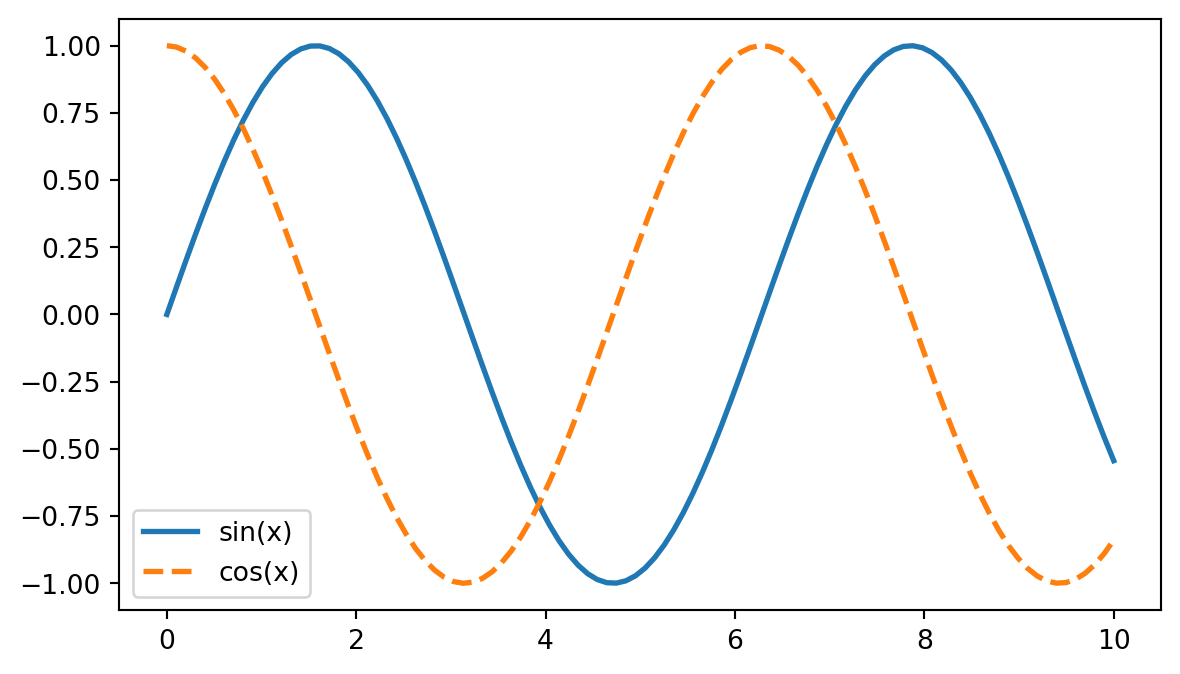

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x), label="sin(x)", linewidth=2)
ax.plot(x, np.cos(x), label="cos(x)", linewidth=2, linestyle="--")
ax.legend()
plt.show()

Key keywords:

- `linewidth`
- `linestyle`: `"-"`, `"--"`, `":"`, `"-."`
- `marker`
- `markersize`
- `color`
- `alpha`

Use line plots for time series, mathematical functions, ordered data, or any situation where connecting the dots is meaningful.

Gotcha: if `x` is not sorted, line plots can produce spaghetti. Sort first or use `scatter()`.

## `ax.scatter(x, y)`: scatter plots

Use scatter plots for independent points where order does not matter. `scatter()` also lets data control point properties.

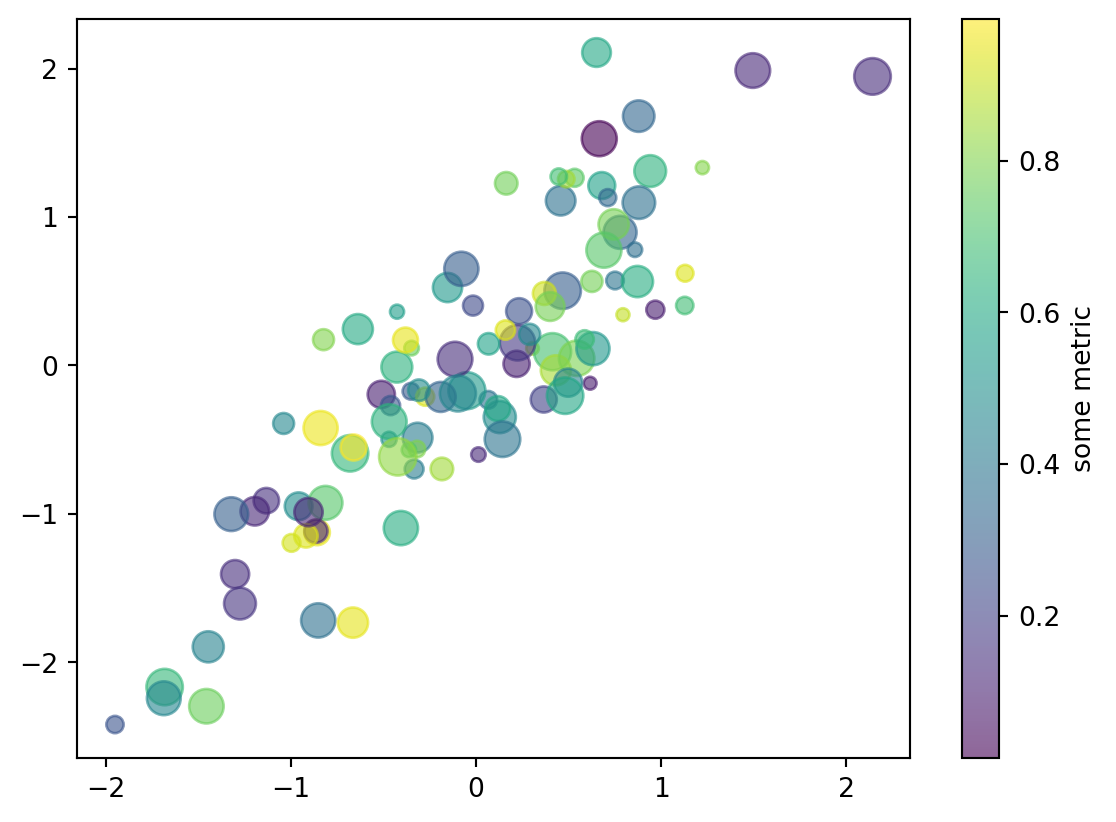

In [2]:
rng = np.random.default_rng(42)
n = 100
x = rng.normal(size=n)
y = x + rng.normal(scale=0.5, size=n)
sizes = rng.uniform(20, 200, n)  # point area
colors = rng.uniform(0, 1, n)    # color-mapped metric

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(x, y, s=sizes, c=colors, alpha=0.6, cmap="viridis")
fig.colorbar(sc, ax=ax, label="some metric")
plt.show()

This is close to `aes(size = ..., color = ...)` in ggplot2, but matplotlib uses `s=` for marker area and `c=` for marker color values.

Important detail: `s=` is marker area in points², not radius. Doubling apparent size means increasing `s` by roughly a factor of four.

```text
plot vs scatter
─────────────────────────────────────────────
plot    → ordered data, connecting line matters
scatter → unordered points, per-point styling matters
```

## Family 2 — Distributional and categorical plots

This family is for counts, categories, and distribution shapes.

## `ax.bar(x, height)`: bar charts

Bar charts show numeric values by category.

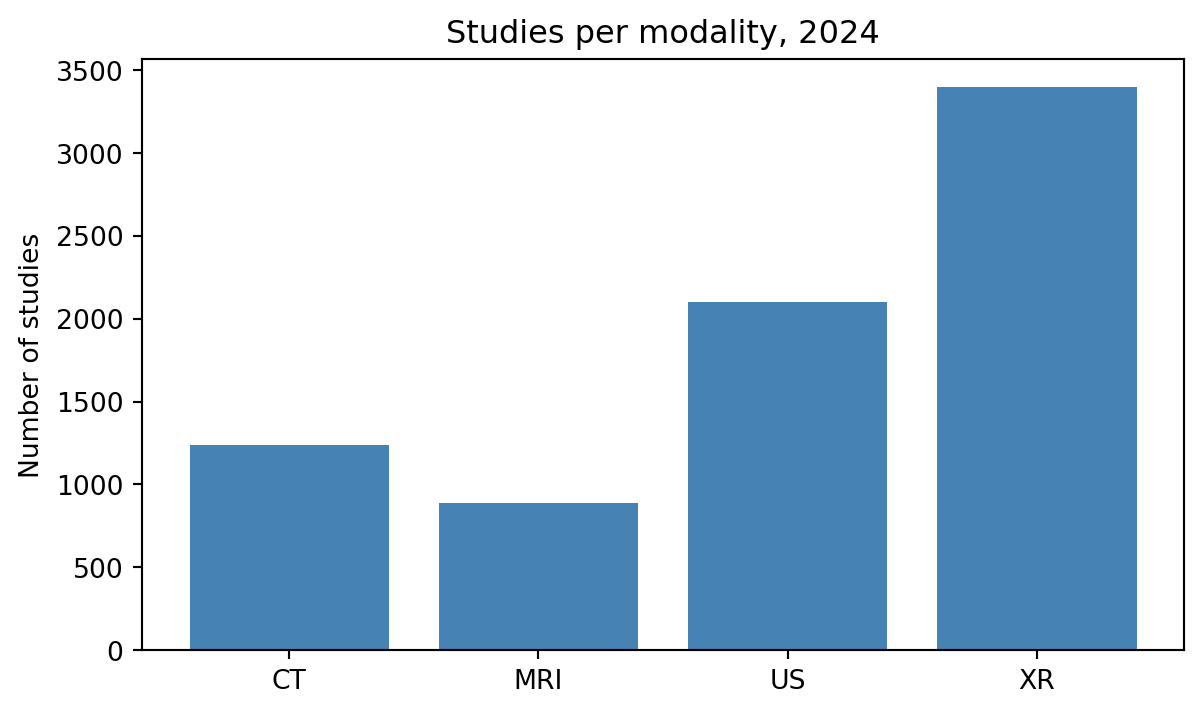

In [3]:
import pandas as pd

df = pd.DataFrame({
    "modality": ["CT", "MRI", "US", "XR"],
    "studies": [1240, 890, 2100, 3400],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df["modality"], df["studies"], color="steelblue")
ax.set_ylabel("Number of studies")
ax.set_title("Studies per modality, 2024")
plt.show()

`ax.barh()` is the horizontal version and is useful when category names are long.

Grouped bars require manual offsets:

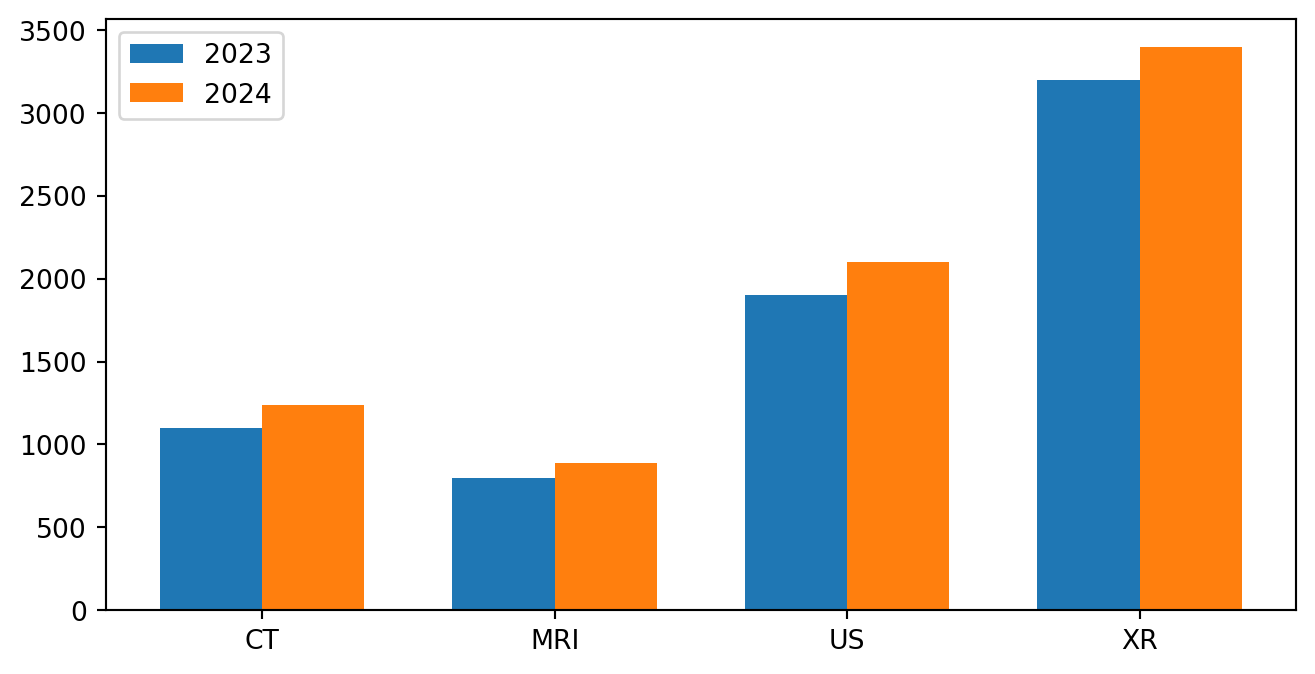

In [4]:
modalities = ["CT", "MRI", "US", "XR"]
year_2023 = [1100, 800, 1900, 3200]
year_2024 = [1240, 890, 2100, 3400]

x = np.arange(len(modalities))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, year_2023, width, label="2023")
ax.bar(x + width / 2, year_2024, width, label="2024")
ax.set_xticks(x)
ax.set_xticklabels(modalities)
ax.legend()
plt.show()

ASCII intuition for grouped bars:

```text
Grouped bars
─────────────────────────────────
      ▆▆ ▆▆
      ▆▆ ▆▆    ▆▆ ▆▆    ▆▆ ▆▆    ▆▆ ▆▆
      ▆▆ ▆▆    ▆▆ ▆▆    ▆▆ ▆▆    ▆▆ ▆▆
       CT       MRI       US       XR
       ↑ ↑
    x-w/2 x+w/2  ← positions computed manually
```

This is one of the places where ggplot2 would be more automatic with dodging. In matplotlib, the offsets are explicit. Seaborn can handle this more directly.

Stacked bars use `bottom=` to stack one series on top of another:

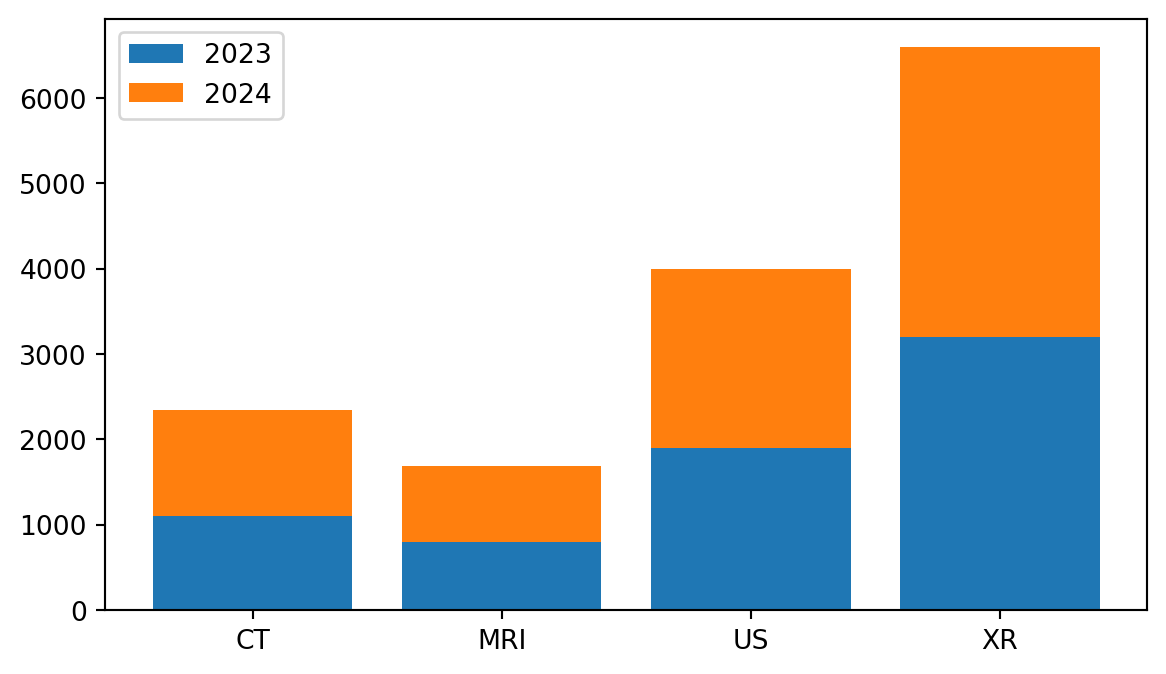

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(modalities, year_2023, label="2023")
ax.bar(modalities, year_2024, bottom=year_2023, label="2024")
ax.legend()
plt.show()

## `ax.hist(values)`: histograms

Histograms show the distribution of one numeric variable. Matplotlib does the binning.

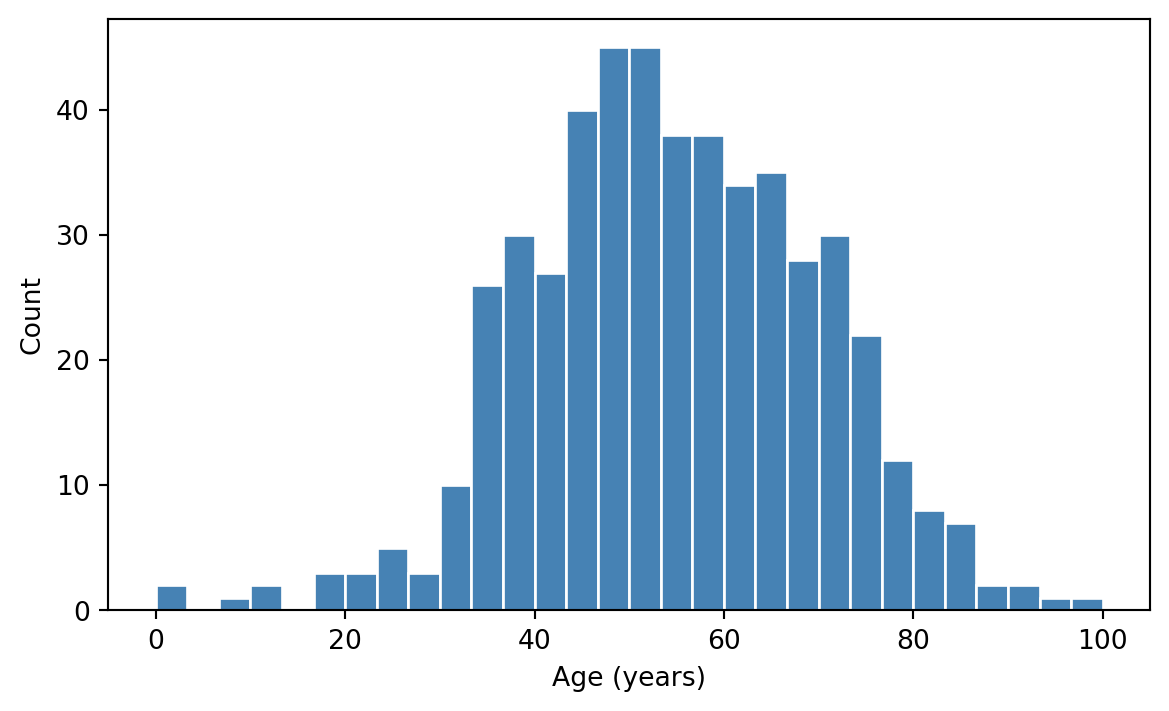

In [6]:
rng = np.random.default_rng(0)
ages = rng.normal(loc=55, scale=15, size=500).clip(0, 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ages, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
plt.show()

Useful keywords:

- `bins`: integer number of bins or explicit bin edges
- `density=True`: normalize to probability density
- `cumulative=True`: cumulative histogram
- `orientation="horizontal"`: horizontal histogram

For overlaying two distributions, use transparency with `alpha`:

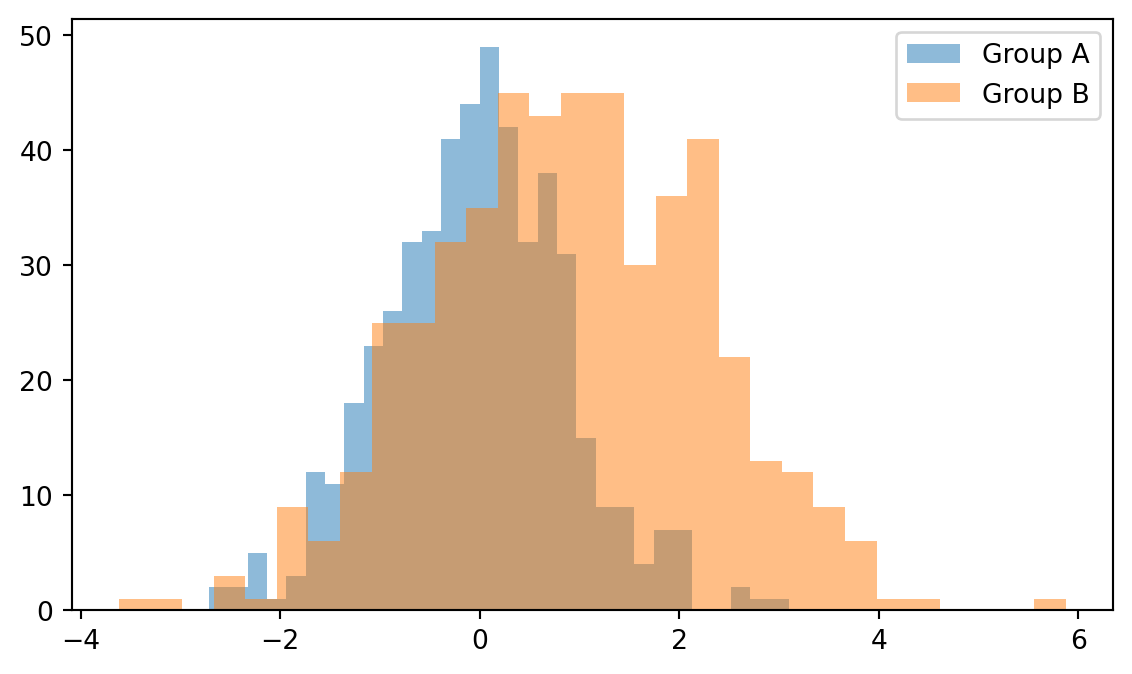

In [7]:
rng = np.random.default_rng(1)
group_a = rng.normal(0, 1, 500)
group_b = rng.normal(1, 1.3, 500)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(group_a, bins=30, alpha=0.5, label="Group A")
ax.hist(group_b, bins=30, alpha=0.5, label="Group B")
ax.legend()
plt.show()

## `ax.boxplot()` and `ax.violinplot()`

Boxplots and violin plots compare distributions across categories. Both expect a list of arrays, one array per category.

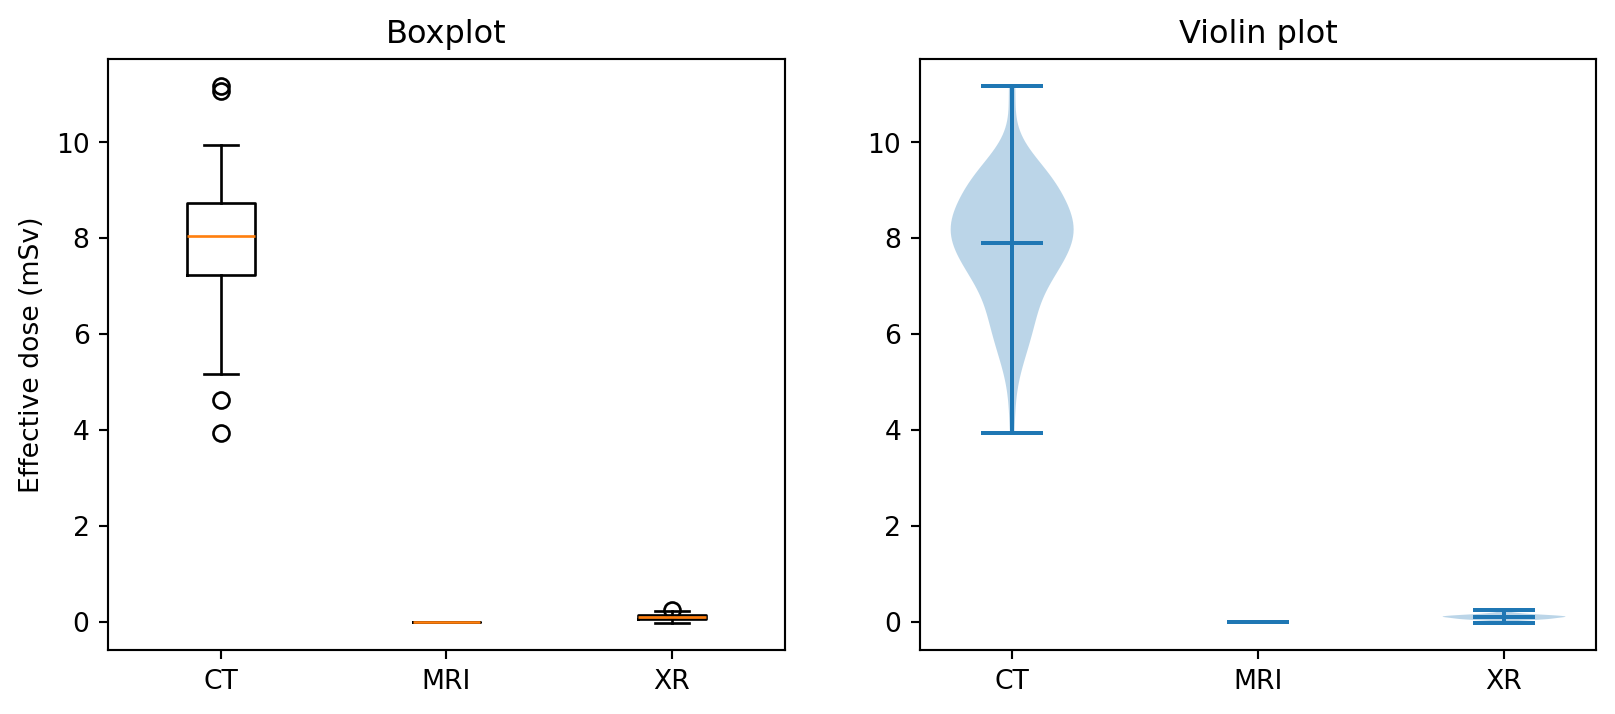

In [8]:
rng = np.random.default_rng(1)
ct_dose = rng.normal(8, 1.5, 100)
mri_dose = np.zeros(100)  # MRI uses no ionizing radiation
xr_dose = rng.normal(0.1, 0.05, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot([ct_dose, mri_dose, xr_dose], tick_labels=["CT", "MRI", "XR"])
axes[0].set_ylabel("Effective dose (mSv)")
axes[0].set_title("Boxplot")

axes[1].violinplot([ct_dose, mri_dose, xr_dose], showmeans=True)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(["CT", "MRI", "XR"])
axes[1].set_title("Violin plot")

plt.show()

Boxplot anatomy:

```text
Boxplot anatomy
─────────────────────────
        ○        ← outliers
        │
       ─┬─       ← upper whisker, often about 1.5 × IQR
        │
      ┌─┴─┐
      │   │      ← upper quartile (Q3)
      ├───┤      ← median
      │   │      ← lower quartile (Q1)
      └─┬─┘
        │
       ─┴─       ← lower whisker
```

Boxplots summarize distributions with a small number of statistics. Violin plots show more of the density shape. Violins are helpful for multimodal data; boxplots are better when quartiles need to be read directly.

## `ax.errorbar(x, y, yerr=...)`: points with uncertainty

Error bars are common for values like mean dose ± SD across scanners.

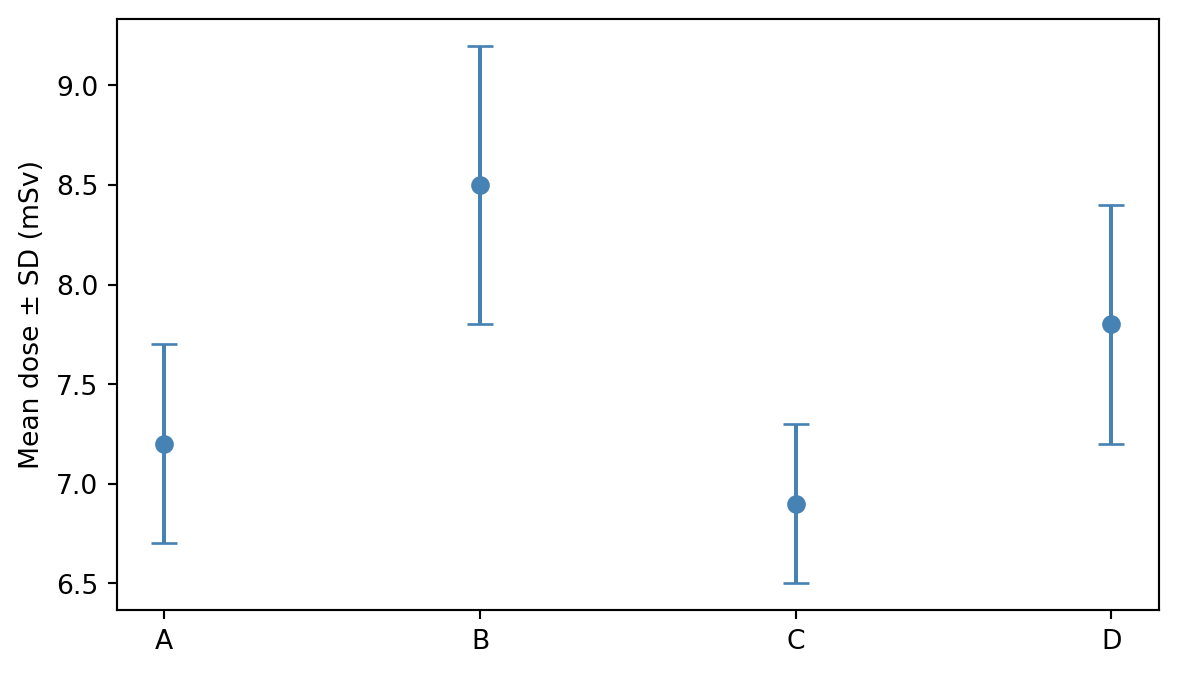

In [9]:
scanners = ["A", "B", "C", "D"]
mean_dose = [7.2, 8.5, 6.9, 7.8]
sd_dose = [0.5, 0.7, 0.4, 0.6]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(scanners, mean_dose, yerr=sd_dose, fmt="o", capsize=5, color="steelblue")
ax.set_ylabel("Mean dose ± SD (mSv)")
plt.show()

`fmt="o"` means circle markers without a connecting line. `fmt="o-"` would connect the points. `capsize=` controls the width of the small T-bars at the ends of the error bars.

## Family 3 — 2D and image-like plots

This is the most important family for radiology work. Images are fundamentally 2D arrays of numbers.

## `ax.imshow(array_2d)`: display a 2D array as an image

`imshow()` displays a CT slice, MRI slice, photograph, heatmap, or any regular 2D matrix.

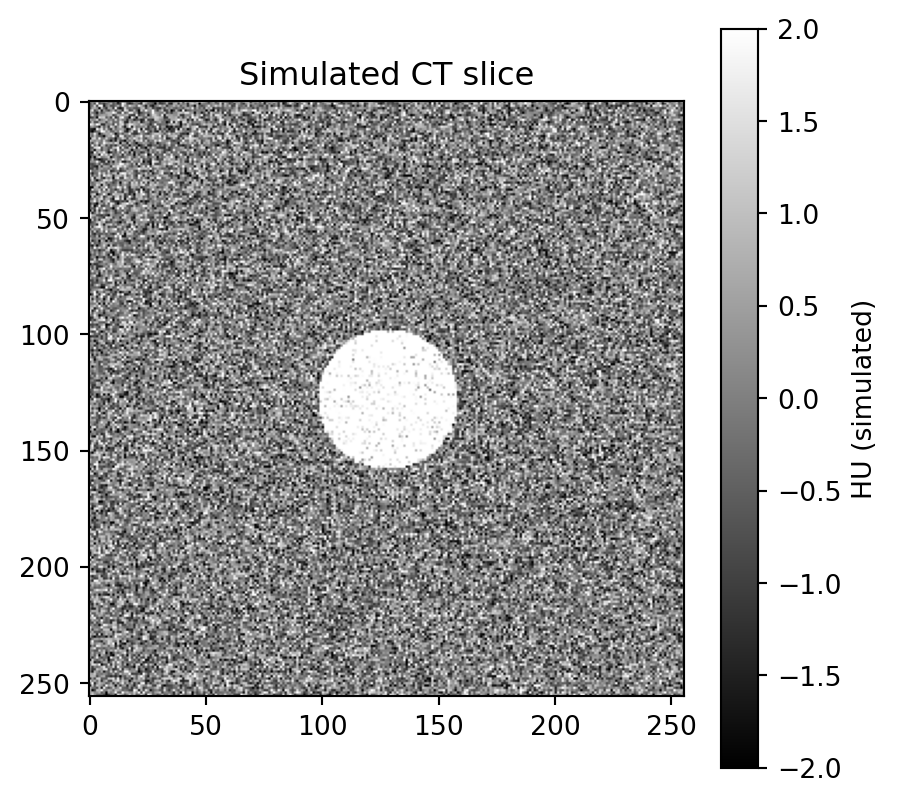

In [10]:
# Simulated CT-like slice: a 2D NumPy array
rng = np.random.default_rng(0)
slice_2d = rng.normal(0, 1, size=(256, 256))

# Add a circular lesion
yy, xx = np.ogrid[:256, :256]
mask = (xx - 128) ** 2 + (yy - 128) ** 2 < 30 ** 2
slice_2d[mask] += 3

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(slice_2d, cmap="gray", vmin=-2, vmax=2)
fig.colorbar(im, ax=ax, label="HU (simulated)")
ax.set_title("Simulated CT slice")
plt.show()

Critical keywords:

- `cmap`: colormap name. For radiology, common choices include `"gray"` or `"bone"`; for functional or heatmap data, `"viridis"` is often a good default.
- `vmin`, `vmax`: data values mapped to the darkest and brightest colors. This is the matplotlib equivalent of windowing. For real HU data, `vmin=-1000, vmax=400` approximates a lung window.
- `aspect="equal"`: preserves square pixels; this is the default.
- `aspect="auto"`: useful for non-spatial 2D data such as spectrograms.
- `origin`: `imshow()` places row 0 at the top by default, following image convention. Use `origin="lower"` for mathematical 2D functions.

```text
imshow origin
─────────────────────────────────────────────
origin="upper" (default)          origin="lower"
row 0 → ┌─────────┐               row N → ┌─────────┐
        │ pixel   │                       │ pixel   │
row N → └─────────┘               row 0 → └─────────┘

For DICOM and most images, keep the default.
For mathematical 2D functions, use origin="lower".
```

## `ax.contour()` and `ax.contourf()`: contour plots

Contour plots visualize 2D scalar fields with iso-value lines, similar to topographic maps.

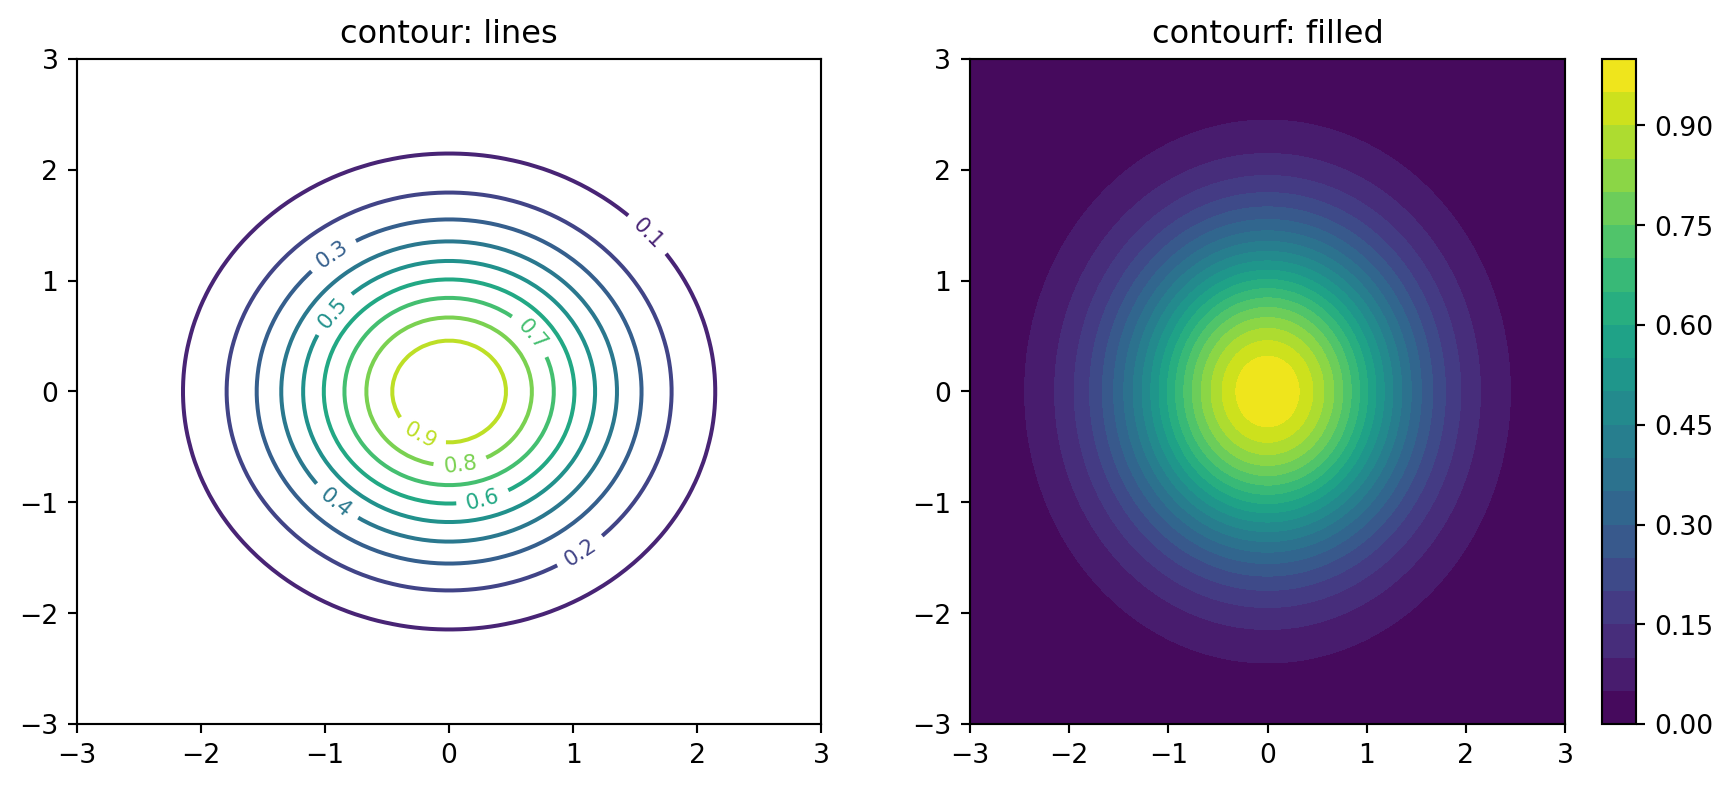

In [11]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-(X ** 2 + Y ** 2) / 2)  # 2D Gaussian

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Line contours
cs = axes[0].contour(X, Y, Z, levels=10, cmap="viridis")
axes[0].clabel(cs, inline=True, fontsize=8)
axes[0].set_title("contour: lines")

# Filled contours
cs2 = axes[1].contourf(X, Y, Z, levels=20, cmap="viridis")
fig.colorbar(cs2, ax=axes[1])
axes[1].set_title("contourf: filled")

plt.show()

The `np.meshgrid()` step is required because contour plots expect 2D grids of x and y coordinates, not just 1D ranges.

A common radiology pattern is `imshow()` for the image plus `contour()` for an ROI overlay:

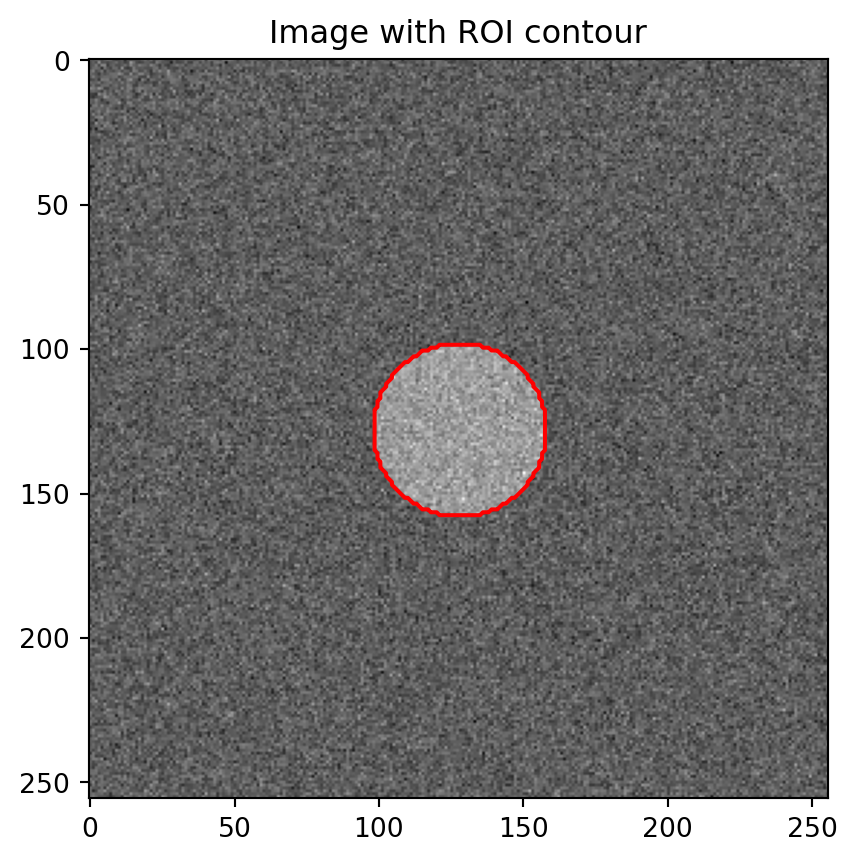

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(slice_2d, cmap="gray")
ax.contour(mask, levels=[0.5], colors="red", linewidths=1.5)
ax.set_title("Image with ROI contour")
plt.show()

This overlay pattern appears often enough in radiology that it deserves deeper treatment later.

## `ax.pcolormesh(X, Y, Z)`: heatmap on an arbitrary grid

`imshow()` assumes pixels are evenly spaced. `pcolormesh()` lets the grid coordinates be explicit, which is useful for non-uniform spacing such as log-spaced frequencies or geographic projections.

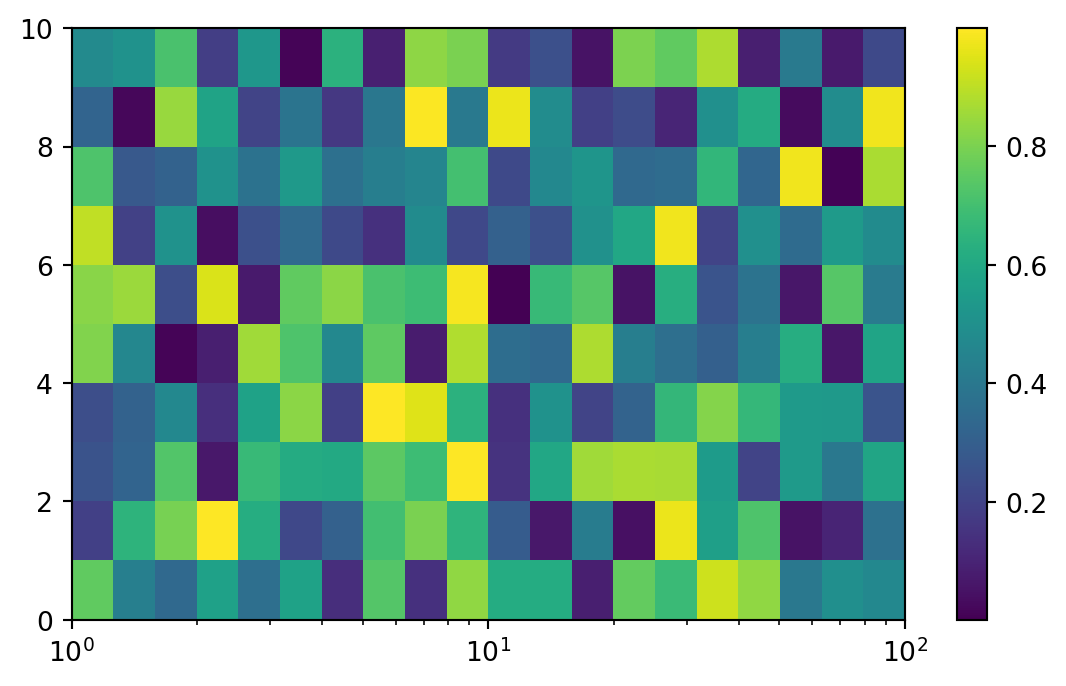

In [13]:
x_edges = np.logspace(0, 2, 21)  # log-spaced from 1 to 100
y_edges = np.linspace(0, 10, 11)
Z = rng.uniform(0, 1, size=(10, 20))

fig, ax = plt.subplots(figsize=(7, 4))
mesh = ax.pcolormesh(x_edges, y_edges, Z, cmap="viridis")
ax.set_xscale("log")
fig.colorbar(mesh, ax=ax)
plt.show()

```text
imshow vs pcolormesh vs contour
─────────────────────────────────────────────
imshow     → pixels are uniform and square
             CT/MRI slices, photographs

pcolormesh → irregular grid or non-uniform spacing
             log axes, geographic maps

contour(f) → iso-value boundaries matter more than per-pixel intensity
```

## Decision flowchart

```text
What does your data look like?
│
├─ Two 1D arrays (x, y)?
│  ├─ Ordered / time series?       → ax.plot
│  ├─ Independent points?          → ax.scatter
│  └─ Points with uncertainty?     → ax.errorbar
│
├─ One 1D array (a sample)?
│  ├─ Want distribution shape?     → ax.hist
│  └─ Compare distributions?       → ax.boxplot / ax.violinplot
│
├─ Categories + numbers?
│  └─ Heights per category         → ax.bar / ax.barh
│
└─ A 2D array (image, matrix)?
   ├─ Display as image             → ax.imshow
   ├─ Iso-value structure          → ax.contour / ax.contourf
   └─ Irregular grid               → ax.pcolormesh
```

## Exercises

### Exercise 1

Generate 200 points where `x ~ Uniform(0, 10)` and `y = 2*x + Normal(0, 2)`. Make a scatter plot, then overlay the line `y = 2*x` on top using `ax.plot`. Use different colors and a legend.

### Exercise 2

Take three samples of size 100:

- `Normal(0, 1)`
- `Normal(0, 2)`
- `Normal(2, 1)`

Make a single figure with overlaid histograms using `alpha=0.5`. Add a legend.

### Exercise 3

Create a 128×128 NumPy array initialized to zero, then add a tumor-like circular region: values inside a circle of radius 20 centered at `(64, 64)` should be set to `1.0`, with Gaussian noise added everywhere.

Display it with `imshow(cmap="gray")`, then overlay a red contour line at level `0.5` to mark the tumor boundary.

### Exercise 4

Compute `Z = sin(X) * cos(Y)` over `X, Y ∈ [-π, π]` using `np.meshgrid`.

Make a side-by-side figure:

- filled contour plot on the left
- `imshow()` of the same array on the right

Notice how `imshow()` flips the y-axis by default because `origin="upper"`.